# Sensitivity Analysis — Spearman's Rho Across Buffer Sizes

## Purpose
This script examines how Spearman's rho and p-values change across different buffer sizes 
to determine which buffer best captures the relationship between groundwater trend and ET/precip ratio.

## Output Table
Rho (ρ) values are displayed for each region and buffer size. 
An asterisk (*) indicates a statistically significant p-value (p < 0.05).

| Region | 1km x 1km | 2km x 2km | 4km x 4km | 10km x 10km |
|---|---|---|---|---|
| Eastern Arkansas | # | # | # | # |
| Central Nebraska | # | # | # | # |
| Southern Idaho | # | # | # | # |
| Southern Kansas | # | # | # | # |
| Southwest US | # | # | # | # |
| Western Texas | # | # | # | # |
| Western Utah | # | # | # | # |

*Example: 0.830* indicates a statistically significant result*

## Libraries used in this script

In [18]:
import pandas as pd
import matplotlib as plt
from tabulate import tabulate

# Load in all CSV that contain spearman rank correlation

In [ ]:
# File paths for Spearman output CSVs for each buffer size
files = {
    "1km": "/capstone/aridgw/outputs/1km/site_summary_spearman_1km.csv",
    "2km": "/capstone/aridgw/outputs/2km/site_summary_spearman_2km.csv",
    "4km": "/capstone/aridgw/outputs/4km/site_summary_spearman_4km.csv",
    "10km": "/capstone/aridgw/outputs/10km/site_summary_spearman_10km.csv",
}

# Read each CSV and tag with its buffer size
dfs = []
for label, path in files.items():
    df = pd.read_csv(path)
    df['buffer'] = label
    dfs.append(df)

# Combine into a single long format table
combined = pd.concat(dfs, ignore_index=True)

#combined.to_csv("/capstone/aridgw/outputs/spearman_sensitivity.csv", index=False)

# View output
combined

,region,rho,p_value,n,buffer
0,ALL,0.527779,0.000082,50,1km
1,Central Nebraska,0.285714,0.534509,7,1km
2,Eastern Arkansas,0.750000,0.052181,7,1km
3,Southern Idaho,-0.400000,0.600000,4,1km
4,Southern Kansas,0.830303,0.002940,10,1km
5,Southwest US,0.666667,0.070988,8,1km
6,Western Texas,0.850000,0.003705,9,1km
7,Western Utah,0.200000,0.747060,5,1km
8,ALL,0.495414,0.000254,50,2km
9,Central Nebraska,0.392857,0.383317,7,2km


# Long to Wide Format
Since the table is hard to see columns and compared. Lets do a wide table to display the information better making it viewable to compare

In [5]:
# Pivot to wide format
wide = combined.pivot(index='region', columns='buffer', values=['rho', 'p_value'])

# Flatten column names (e.g. rho_1km, p_value_1km)
wide.columns = [f"{stat}_{buf}" for stat, buf in wide.columns]
wide = wide.reset_index()

# Reorder columns by buffer size
col_order = ['region'] + [f"{stat}_{buf}" for buf in ['1km','2km','4km','10km'] for stat in ['rho','p_value']]
wide = wide[col_order]

# Produce table as output for sensitivity analysis
wide.to_csv("/capstone/aridgw/outputs/spearman_sensitivity_table.csv", index=False)

# View table
wide

,region,rho_1km,p_value_1km,rho_2km,p_value_2km,rho_4km,p_value_4km,rho_10km,p_value_10km
0,ALL,0.527779,0.000082,0.495414,0.000254,0.487827,0.000326,0.448259,0.001096
1,Central Nebraska,0.285714,0.534509,0.392857,0.383317,0.392857,0.383317,0.321429,0.482072
2,Eastern Arkansas,0.750000,0.052181,0.964286,0.000454,0.500000,0.253170,0.428571,0.337368
3,Southern Idaho,-0.400000,0.600000,-0.200000,0.800000,-0.200000,0.800000,-0.400000,0.600000
4,Southern Kansas,0.830303,0.002940,0.793939,0.006100,0.781818,0.007547,0.781818,0.007547
5,Southwest US,0.666667,0.070988,0.500000,0.207031,0.238095,0.570156,0.333333,0.419753
6,Western Texas,0.850000,0.003705,0.766667,0.015944,0.816667,0.007225,0.950000,0.000088
7,Western Utah,0.200000,0.747060,0.200000,0.747060,0.200000,0.747060,0.200000,0.747060


# Sensitivity Analysis
With Spearman rank correlations computed for all buffer sizes, we can now compare how the overall rho changes across scales. A decreasing trend supports the 1km buffer as the strongest estimate for this analysis.

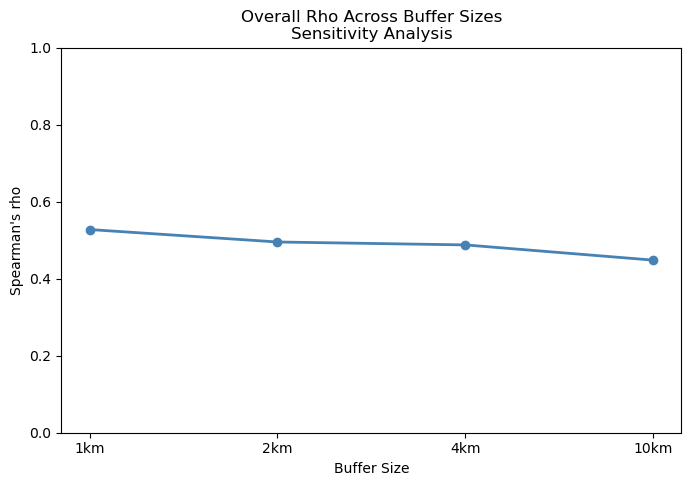

In [14]:
# Add buffer sizes
buffers = ['1km', '2km', '4km', '10km']

# Use the overall rho for each buffer
overall = combined[combined['region'] == 'ALL'].set_index('buffer').reindex(buffers)

# Start Plot

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(buffers, overall['rho'], marker='o', color='steelblue', linewidth=2)

ax.set_xlabel('Buffer Size')
ax.set_ylabel("Spearman's rho")
ax.set_title('Overall Rho Across Buffer Sizes\nSensitivity Analysis')
ax.set_ylim(0, 1)
plt.show()


 - 1km has the strongest rho (0.528) and it consistently decreases as buffer size grows. This means the 1km buffer best captures the relationship between groundwater trend and ET/precip ratio. As the buffer gets larger, you're likely averaging over more heterogeneous land cover and ET conditions, which dilutes the signal

In [22]:
# Build display table with asterisks for significant p-values
buffers = ['1km', '2km', '4km', '10km']

# Layout of table
def format_cell(row, buf):

    rho = row[f'rho_{buf}']

    p = row[f'p_value_{buf}']
    # Add a star if p-value is significant
    star = '*' if p < 0.05 else ''
    
    return f"{rho:.3f}{star}"

# Exclude ALL row
table = wide[wide['region'] != 'ALL'].copy()
for buf in buffers:
    table[buf] = table.apply(lambda row: format_cell(row, buf), axis=1)

display_table = table[['region'] + buffers].set_index('region')
print(display_table.to_markdown())

# Export table to csv
display_table.to_csv("/capstone/aridgw/outputs/sensitivity_results.csv")

| region           | 1km    | 2km    | 4km    | 10km   |
|:-----------------|:-------|:-------|:-------|:-------|
| Central Nebraska | 0.286  | 0.393  | 0.393  | 0.321  |
| Eastern Arkansas | 0.750  | 0.964* | 0.500  | 0.429  |
| Southern Idaho   | -0.400 | -0.200 | -0.200 | -0.400 |
| Southern Kansas  | 0.830* | 0.794* | 0.782* | 0.782* |
| Southwest US     | 0.667  | 0.500  | 0.238  | 0.333  |
| Western Texas    | 0.850* | 0.767* | 0.817* | 0.950* |
| Western Utah     | 0.200  | 0.200  | 0.200  | 0.200  |
